# Chen et al. 2026 — NWB Data Access Demo

**Dataset:** Dombeck Lab, Northwestern University  
**Publication:** Chen, He et al. 2026 — "Leucine-rich repeat kinase 2 impairs the release sites of Parkinson's disease vulnerable dopamine axons" (in preparation)  
**Analysis code:** [DombeckLab/lrrk2_photometry_analysis](https://github.com/DombeckLab/lrrk2_photometry_analysis)

This notebook demonstrates how to read all data streams from a single NWB session file:

| Section | Contents |
|---------|----------|
| 1 | Fiber photometry metadata (FiberPhotometryTable, devices, indicator) |
| 2 | Raw fiber photometry (470 nm signal + 405 nm isosbestic) |
| 3 | Processed fiber photometry (corrected signal, ΔF/F) |
| 4 | Optogenetic stimulation epochs |
| 5 | Raw FP + stimulation overlay |
| 6 | ΔF/F aligned to stimulation onset |
| 7 | Optogenetics metadata (ndx-optogenetics) |
| 8 | Behavior (treadmill velocity and acceleration) |
| 9 | Combined ΔF/F and velocity |
| 10 | NWB file structure overview |

## Setup

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from pynwb import read_nwb
import ndx_optogenetics  # register namespace before opening the file

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

## Load NWB file

Update the path below to point to your NWB file. This demo uses a full-session file.
Stub (truncated) files have the same structure but contain only the first 100 samples
and will not have optogenetic epochs (stimulation begins after the first second).

In [20]:
nwb_path = "/Users/weian/lrrk2_data/nwb-output/sub-4007-anxa-gs_ses-2025-08-13-0005.nwb"

nwbfile = read_nwb(nwb_path)

print(f"Session ID:          {nwbfile.session_id}")
print(f"Session description: {nwbfile.session_description}")
print(f"Subject ID:          {nwbfile.subject.subject_id}")
print(f"Species:             {nwbfile.subject.species}")
print(f"Genotype:            {nwbfile.subject.genotype}")
print(f"Sex:                 {nwbfile.subject.sex}")

Session ID:          2025-08-13-0005
Session description: Fiber photometry recording of GRAB-DA3m dopamine fluorescence in the dorsal lateral striatum (DLS) during optogenetic activation of Anxa1+ dopamine neuron cell bodies in SNc (ChRmine, 635 nm) in an awake head-fixed LRRK2-G2019S mouse on a treadmill. Data sources: fiber photometry (raw multiplexed fluorescence at 2 kHz), optogenetic stimulation TTL, and treadmill velocity.

Subject ID:          4007-anxa-gs
Species:             Mus musculus
Genotype:            LRRK2-G2019S
Sex:                 U


## 1. Fiber photometry metadata

Recording metadata (brain location, wavelengths, indicator, hardware) is stored via the
[ndx-fiber-photometry](https://github.com/catalystneuro/ndx-fiber-photometry) and
[ndx-ophys-devices](https://github.com/catalystneuro/ndx-ophys-devices) extensions.

In [21]:
fp_meta = nwbfile.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table

print(f"FP table rows: {len(fp_table.to_dataframe())}")
print(f"Recording location:       {fp_table['location'][0]}")
print(f"Excitation wavelength:    {fp_table['excitation_wavelength_in_nm'][0]} nm")
print(f"Emission wavelength:      {fp_table['emission_wavelength_in_nm'][0]} nm")

ind = fp_table["indicator"][0]
print(f"\nIndicator label:          {ind.label}")
print(f"Indicator description:    {ind.description}")

# Excitation source devices
es_signal = nwbfile.devices["signal_excitation_source"]
es_isos   = nwbfile.devices["isosbestic_excitation_source"]
print(f"\nSignal source (470 nm):   {es_signal.name}")
print(f"  model:                  {es_signal.model.name}  ({es_signal.model.manufacturer})")
print(f"  model number:           {es_signal.model.model_number}")
print(f"Isosbestic source (405 nm): {es_isos.name}")
print(f"  model:                  {es_isos.model.name}  ({es_isos.model.manufacturer})")
print(f"  model number:           {es_isos.model.model_number}")

# Optical fiber (Anxa group → DLS; Calb group → use 'optical_fiber_dms')
of_device = nwbfile.devices["optical_fiber_dls"]
of_model = of_device.model
fi = of_device.fiber_insertion
print(f"\nOptical fiber (DLS, fiber photometry):")
print(f"  model number:           {of_model.model_number}  ({of_model.manufacturer})")
print(f"  core diameter:          {of_model.core_diameter_in_um:.0f} µm")
print(f"  numerical aperture:     {of_model.numerical_aperture}")
print(f"  implant AP:             {fi.insertion_position_ap_in_mm} mm")
print(f"  implant ML:             {fi.insertion_position_ml_in_mm} mm")
print(f"  implant DV:             {fi.insertion_position_dv_in_mm} mm  (from dura surface)")
print(f"  hemisphere:             {fi.hemisphere}")

FP table rows: 4
Recording location:       dorsal lateral striatum
Excitation wavelength:    470.0 nm
Emission wavelength:      520.0 nm

Indicator label:          GRAB-DA3m
Indicator description:    GPCR-based dopamine fluorescent sensor (dopamine indicator). Excitation at 470 nm (functional) and 405 nm (isosbestic control); emission ~520 nm. Injected into dorsal lateral striatum (Anxa-LRRK2 group).

Signal source (470 nm):   signal_excitation_source
  model:                  thorlabs_signal_led_model  (Thorlabs)
  model number:           M470F3
Isosbestic source (405 nm): isosbestic_excitation_source
  model:                  thorlabs_isosbestic_led_model  (Thorlabs)
  model number:           M405FP1

Optical fiber (DLS, fiber photometry):
  model number:           MFC_200/250-0.66_2.0mm_ZF1.25(G)_FLT  (Doric Lenses)
  core diameter:          200 µm
  numerical aperture:     0.66
  implant AP:             0.5 mm
  implant ML:             1.8 mm
  implant DV:             2.0 mm  (from

## 2. Raw fiber photometry

The raw fluorescence traces acquired at 2 kHz by the Axon Digidata 1550B are stored
in `acquisition/`. The 470 nm excitation (GRAB-DA3m signal) and 405 nm excitation
(isosbestic control for movement artifacts) are demultiplexed from the interleaved
acquisition using the function-generator TTL.

Both channels are stored as `FiberPhotometryResponseSeries` at the native 2 kHz rate.

In [22]:
raw_sig = nwbfile.acquisition["FiberPhotometryResponseSeriesRawSignal"]
raw_ref = nwbfile.acquisition["FiberPhotometryResponseSeriesIsosbesticControl"]

sig_data = raw_sig.data[:]
ref_data = raw_ref.data[:]
# Separate timestamps per channel — demultiplexed LED cycles yield different sample counts
raw_time_sig = np.asarray(raw_sig.get_timestamps())
raw_time_ref = np.asarray(raw_ref.get_timestamps())

print(f"Signal (470 nm):    {sig_data.shape},  range [{sig_data.min():.2f}, {sig_data.max():.2f}] a.u.")
print(f"Reference (405 nm): {ref_data.shape},  range [{ref_data.min():.2f}, {ref_data.max():.2f}] a.u.")
print(f"Sampling:           irregular timestamps (transition samples between LED cycles discarded)")
print(f"Avg. rate (signal): {len(sig_data) / (raw_time_sig[-1] - raw_time_sig[0]):.0f} Hz")
print(f"Time range:         {raw_time_sig[0]:.2f} – {raw_time_sig[-1]:.2f} s")

Signal (470 nm):    (1055733,),  range [0.59, 0.78] a.u.
Reference (405 nm): (1055138,),  range [0.64, 0.73] a.u.
Sampling:           irregular timestamps (transition samples between LED cycles discarded)
Avg. rate (signal): 800 Hz
Time range:         0.00 – 1319.30 s


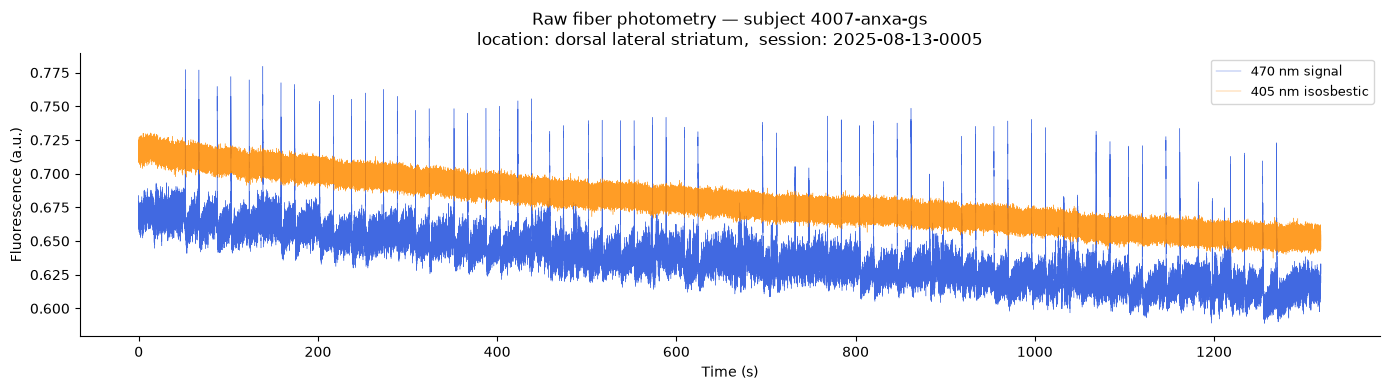

In [23]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(raw_time_sig, sig_data, linewidth=0.3, color="royalblue",  label="470 nm signal")
ax.plot(raw_time_ref, ref_data, linewidth=0.3, color="darkorange", alpha=0.85, label="405 nm isosbestic")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Fluorescence (a.u.)")
ax.set_title(
    f"Raw fiber photometry — subject {nwbfile.subject.subject_id}\n"
    f"location: {fp_table['location'][0]},  session: {nwbfile.session_id}"
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("raw_fp.png", dpi=220)
plt.show()

## 3. Processed fiber photometry

MATLAB script `LRRK2_binning_and_processing.m` re-bins the traces to 100 Hz
(camera-trigger-aligned) and applies two processing steps, stored in `processing/ophys/`:

| Series | Description |
|--------|-------------|
| `FiberPhotometryResponseSeriesCorrectedSignal` | Baseline-subtracted 470 nm (sliding 8th-percentile, 20 s window) |
| `FiberPhotometryResponseSeriesCorrectedIsosbesticControl` | Same for 405 nm |
| `FiberPhotometryResponseSeriesDfOverF` | % ΔF/F of corrected 470 nm, smoothed (200 ms moving mean) |
| `FiberPhotometryResponseSeriesDfOverFIsosbesticControl` | % ΔF/F of corrected 405 nm |

All four series are at **100 Hz**.

In [24]:
ophys = nwbfile.processing["ophys"]

corr   = ophys["FiberPhotometryResponseSeriesCorrectedSignal"]
corr_i = ophys["FiberPhotometryResponseSeriesCorrectedIsosbesticControl"]
dff    = ophys["FiberPhotometryResponseSeriesDfOverF"]
dff_i  = ophys["FiberPhotometryResponseSeriesDfOverFIsosbesticControl"]

corr_data = corr.data[:]
corr_time = np.asarray(corr.get_timestamps())  # camera trigger times (ABF clock)
dff_data  = dff.data[:]
dff_time  = np.asarray(dff.get_timestamps())

print(f"Corrected signal:  {corr_data.shape},  unit={corr.unit}")
print(f"ΔF/F:              {dff_data.shape},   unit={dff.unit}")
print(f"Time range:        {dff_time[0]:.2f} – {dff_time[-1]:.2f} s  (camera-trigger-aligned)")
print(f"ΔF/F range:        {dff_data.min():.3f} to {dff_data.max():.3f} %")

Corrected signal:  (129307,),  unit=a.u.
ΔF/F:              (129307,),   unit=a.u.
Time range:        21.06 – 1313.82 s  (camera-trigger-aligned)
ΔF/F range:        -6.848 to 117.214 %


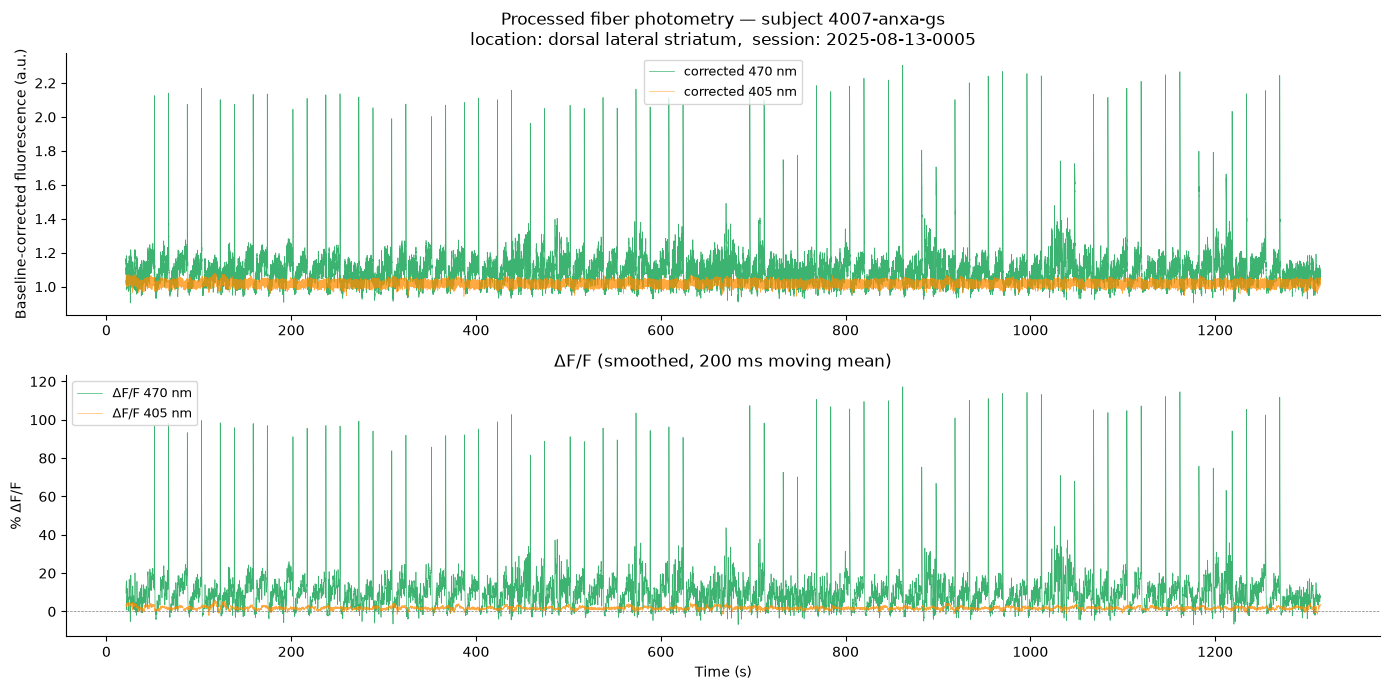

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(corr_time, corr_data, linewidth=0.5, color="mediumseagreen",
             label="corrected 470 nm")
axes[0].plot(corr_time, corr_i.data[:], linewidth=0.4, color="darkorange",
             alpha=0.75, label="corrected 405 nm")
axes[0].set_ylabel("Baseline-corrected fluorescence (a.u.)")
axes[0].set_title(
    f"Processed fiber photometry — subject {nwbfile.subject.subject_id}\n"
    f"location: {fp_table['location'][0]},  session: {nwbfile.session_id}"
)
axes[0].legend(fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(dff_time, dff_data, linewidth=0.5, color="mediumseagreen",
             label="ΔF/F 470 nm")
axes[1].plot(dff_time, dff_i.data[:], linewidth=0.4, color="darkorange",
             alpha=0.75, label="ΔF/F 405 nm")
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("% ΔF/F")
axes[1].set_title("ΔF/F (smoothed, 200 ms moving mean)")
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("processed_fp.png", dpi=220)
plt.show()

## 4. Optogenetic stimulation epochs

Stimulation epochs are stored as an `OptogeneticEpochsTable` in `intervals/`.
Each row is one contiguous TTL-high block extracted from the 100 Hz binned TTL
column in `*_data.mat`. At 100 Hz resolution (10 ms/sample), the 8 ms on / 8 ms off
pulse pattern within each 500 ms train appears as a single high block of ~330 ms
(because the 8 ms on-phase dominates each 10 ms bin).

Stimulation parameters (confirmed from manuscript):
- Pulse shape: 8 ms on / 8 ms off (~31 pulses per 500 ms train)
- Powers: 0.1, 0.5, 1.0, 4.0 mW at cannula tip (pseudorandom order)
- At least 20 s between trains; repeated 8 times per power level

In [26]:
opto_epochs = nwbfile.intervals["OptogeneticEpochsTable"]
opto_df = opto_epochs.to_dataframe()

print(f"Total stimulation epochs: {len(opto_df)}")
print(f"\nFirst 5 epochs:")
opto_df[["start_time", "stop_time", "pulse_length_in_ms", "period_in_ms",
          "number_pulses_per_pulse_train", "number_trains",
          "intertrain_interval_in_ms", "power_in_mW", "wavelength_in_nm"]].head(5)

Total stimulation epochs: 122

First 5 epochs:


,start_time,stop_time,pulse_length_in_ms,period_in_ms,number_pulses_per_pulse_train,number_trains,intertrain_interval_in_ms,power_in_mW,wavelength_in_nm
id,,,,,,,,,
0,51.7635,52.0935,8.0,16.0,31,1,20000.0,NaN,635.0
1,67.0900,67.4200,8.0,16.0,31,1,20000.0,NaN,635.0
2,87.4055,87.7355,8.0,16.0,31,1,20000.0,NaN,635.0
3,102.7320,103.0620,8.0,16.0,31,1,20000.0,NaN,635.0
4,123.0475,123.3770,8.0,16.0,31,1,20000.0,NaN,635.0


In [27]:
durations = opto_df["stop_time"] - opto_df["start_time"]
isis = opto_df["start_time"].diff().dropna()

print(f"Epoch duration:       mean = {durations.mean():.3f} s,  std = {durations.std():.3f} s")
print(f"Inter-epoch interval: mean = {isis.mean():.1f} s,  min = {isis.min():.1f} s")

Epoch duration:       mean = 0.215 s,  std = 0.192 s
Inter-epoch interval: mean = 10.1 s,  min = 0.0 s


## 5. Raw fiber photometry with stimulation overlay

A short window of the raw 470 nm signal and 405 nm isosbestic reference,
with optogenetic stimulation epochs shaded in red. The 405 nm channel serves
as a motion-artifact control — it should not respond to dopamine release.

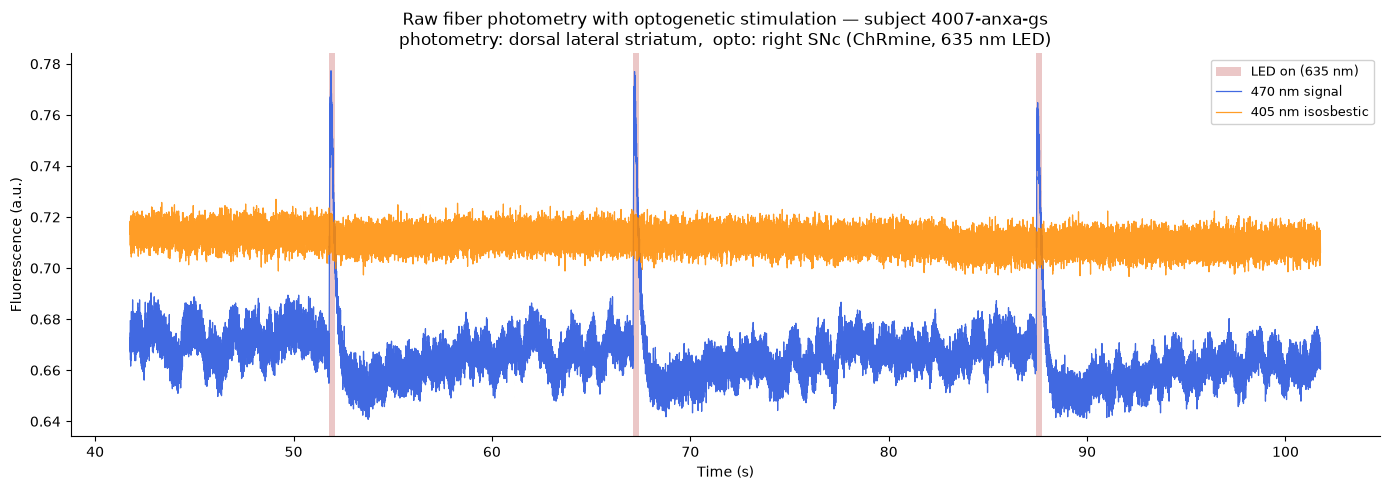

Window: 41.8 – 101.8 s  (3 stimulation epochs)


In [28]:
first_onset = opto_df["start_time"].iloc[0]
t_win_start = max(first_onset - 10.0, raw_time_sig[0])
t_win_stop  = t_win_start + 60.0

sig_mask = (raw_time_sig >= t_win_start) & (raw_time_sig <= t_win_stop)
ref_mask = (raw_time_ref >= t_win_start) & (raw_time_ref <= t_win_stop)
t_sig_w  = raw_time_sig[sig_mask]
t_ref_w  = raw_time_ref[ref_mask]
sig_w    = sig_data[sig_mask]
ref_w    = ref_data[ref_mask]

epochs_in_win = opto_df[
    (opto_df["stop_time"] >= t_win_start) & (opto_df["start_time"] <= t_win_stop)
]

fig, ax = plt.subplots(figsize=(14, 5))

stim_color = "firebrick"
for i, (_, ep) in enumerate(epochs_in_win.iterrows()):
    ax.axvspan(
        ep["start_time"], ep["stop_time"],
        color=stim_color, alpha=0.25, linewidth=0,
        label="LED on (635 nm)" if i == 0 else None,
    )

ax.plot(t_sig_w, sig_w, linewidth=0.9, color="royalblue",  label="470 nm signal")
ax.plot(t_ref_w, ref_w, linewidth=0.9, color="darkorange", alpha=0.85, label="405 nm isosbestic")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Fluorescence (a.u.)")
ax.set_title(
    f"Raw fiber photometry with optogenetic stimulation — subject {nwbfile.subject.subject_id}\n"
    f"photometry: {fp_table['location'][0]},  opto: right SNc (ChRmine, 635 nm LED)"
)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("raw_fp_stim.png", dpi=220)
plt.show()

print(f"Window: {t_win_start:.1f} – {t_win_stop:.1f} s  ({len(epochs_in_win)} stimulation epochs)")

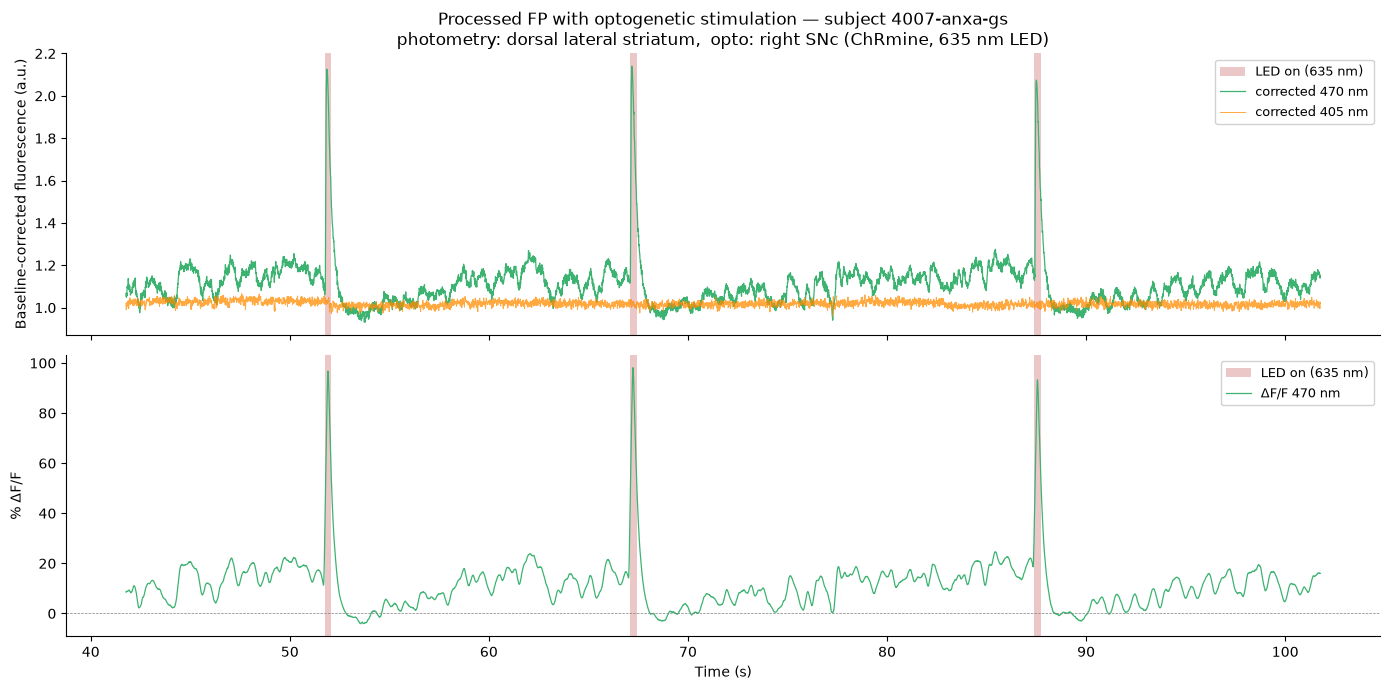

In [29]:
# Processed FP + stimulation overlay (same 60-second window)

# Reuse window / epoch subset from the raw FP overlay above
fp_mask_proc = (corr_time >= t_win_start) & (corr_time <= t_win_stop)
t_proc       = corr_time[fp_mask_proc]
corr_w       = corr_data[fp_mask_proc]
corr_i_w     = corr_i.data[:][fp_mask_proc]
dff_w        = dff_data[fp_mask_proc]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for i, (_, ep) in enumerate(epochs_in_win.iterrows()):
    lbl = "LED on (635 nm)" if i == 0 else None
    axes[0].axvspan(ep["start_time"], ep["stop_time"], color=stim_color, alpha=0.25, linewidth=0, label=lbl)
    axes[1].axvspan(ep["start_time"], ep["stop_time"], color=stim_color, alpha=0.25, linewidth=0, label=lbl)

axes[0].plot(t_proc, corr_w,   linewidth=0.9, color="mediumseagreen", label="corrected 470 nm")
axes[0].plot(t_proc, corr_i_w, linewidth=0.7, color="darkorange", alpha=0.75, label="corrected 405 nm")
axes[0].set_ylabel("Baseline-corrected fluorescence (a.u.)")
axes[0].set_title(
    f"Processed FP with optogenetic stimulation — subject {nwbfile.subject.subject_id}\n"
    f"photometry: {fp_table['location'][0]},  opto: right SNc (ChRmine, 635 nm LED)"
)
axes[0].legend(loc="upper right", fontsize=9, framealpha=0.9)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(t_proc, dff_w, linewidth=0.9, color="mediumseagreen", label="ΔF/F 470 nm")
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("% ΔF/F")
axes[1].legend(loc="upper right", fontsize=9, framealpha=0.9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("processed_fp_stim.png", dpi=220)
plt.show()

## 6. ΔF/F aligned to stimulation onset

ΔF/F signal (100 Hz, smoothed) around the first stimulation epoch, with the
stimulation window shaded. This is the primary signal used in the paper for
analysis of optogenetically evoked dopamine release.

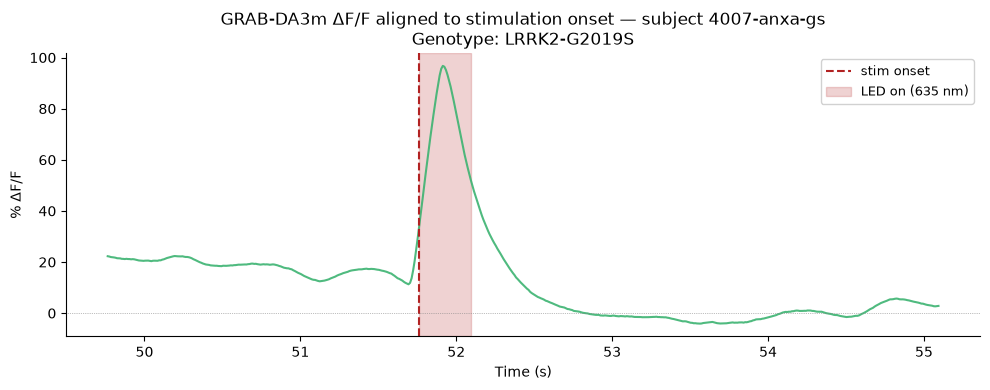

In [30]:
stim_onset  = opto_df["start_time"].iloc[0]
stim_offset = opto_df["stop_time"].iloc[0]
pre_s  = 2.0
post_s = 3.0

mask = (dff_time >= stim_onset - pre_s) & (dff_time <= stim_offset + post_s)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(dff_time[mask], dff_data[mask], color="mediumseagreen", linewidth=1.5, alpha=0.9)
ax.axvline(stim_onset,  color=stim_color, linestyle="--", linewidth=1.5, label="stim onset")
ax.axvspan(stim_onset, stim_offset, color=stim_color, alpha=0.20,
           label="LED on (635 nm)")
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")

ax.set_xlabel("Time (s)")
ax.set_ylabel("% ΔF/F")
ax.set_title(
    f"GRAB-DA3m ΔF/F aligned to stimulation onset — subject {nwbfile.subject.subject_id}\n"
    f"Genotype: {nwbfile.subject.genotype}"
)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("processed_fp_stim_2.png", dpi=220)
plt.show()

## 7. Optogenetics metadata (ndx-optogenetics)

Rich device and provenance metadata is stored via the
[ndx-optogenetics](https://github.com/catalystneuro/ndx-optogenetics) extension
in `lab_meta_data["optogenetic_experiment_metadata"]`.

This includes: LED model, optical fiber (implant coordinates),
viral vector (construct name, titer), and effector (ChRmine).

In [31]:
opto_meta = nwbfile.lab_meta_data["optogenetic_experiment_metadata"]

print(f"Stimulation software:  {opto_meta.stimulation_software}")
print()

# Sites table
sites_table = opto_meta.optogenetic_sites_table
n_sites = len(sites_table.to_dataframe())
print(f"Optogenetic sites: {n_sites} row(s)")
for i in range(n_sites):
    eff = sites_table["effector"][i]
    print(f"  row {i}: effector={eff.name}, label={eff.label}")
print()

# LED (excitation source)
led = nwbfile.devices["led_635nm"]
led_model = led.model
print(f"Excitation source (LED):")
print(f"  name:          {led.name}")
print(f"  manufacturer:  {led_model.manufacturer}")
print(f"  model number:  {led_model.model_number}")
print(f"  source type:   {led_model.source_type}")
print()

# Optical fiber (SNc implant)
opto_fiber = nwbfile.devices["optical_fiber_snc"]
opto_fiber_model = opto_fiber.model
fi_opto = opto_fiber.fiber_insertion
print(f"Optical fiber (SNc, optogenetics):")
print(f"  model number:  {opto_fiber_model.model_number}  ({opto_fiber_model.manufacturer})")
print(f"  core diameter: {opto_fiber_model.core_diameter_in_um:.0f} µm")
print(f"  implant AP:    {fi_opto.insertion_position_ap_in_mm} mm")
print(f"  implant ML:    {fi_opto.insertion_position_ml_in_mm} mm")
print(f"  implant DV:    {fi_opto.insertion_position_dv_in_mm} mm  (from dura surface)")
print(f"  hemisphere:    {fi_opto.hemisphere}")
print()

# Viral vector (LabelledDict — iterate by key)
vv_dict = opto_meta.optogenetic_viruses.viral_vectors
virus = vv_dict[next(iter(vv_dict))]
print(f"Viral vector:")
print(f"  construct:     {virus.construct_name}")
print(f"  manufacturer:  {virus.manufacturer}")
print(f"  titer:         {virus.titer_in_vg_per_ml:.2e} vg/mL")
print()

# Virus injection
vi_dict = opto_meta.optogenetic_virus_injections.viral_vector_injections
inj = vi_dict[next(iter(vi_dict))]
print(f"Virus injection (SNc):")
print(f"  location:      {inj.location}")
print(f"  hemisphere:    {inj.hemisphere}")
print(f"  volume:        {inj.volume_in_uL} µL  (4 depths × 0.1 µL)")
print(f"  AP:            {inj.ap_in_mm} mm,  ML: {inj.ml_in_mm} mm,  DV: {inj.dv_in_mm} mm")

Stimulation software:  Doric Studio (Doric Lenses)

Optogenetic sites: 1 row(s)
  row 0: effector=ChRmine_right, label=ChRmine

Excitation source (LED):
  name:          led_635nm
  manufacturer:  Doric Lenses
  model number:  LEDFRJ_635
  source type:   LED

Optical fiber (SNc, optogenetics):
  model number:  MFC_400/430-0.66_4.0mm_TS3.0_C60  (Doric Lenses)
  core diameter: 400 µm
  implant AP:    -3.2 mm
  implant ML:    1.6 mm
  implant DV:    4.0 mm  (from dura surface)
  hemisphere:    right

Viral vector:
  construct:     pAAV-Ef1a-DIO-ChRmine-mScarlet-WPRE
  manufacturer:  Addgene
  titer:         2.20e+13 vg/mL

Virus injection (SNc):
  location:      substantia nigra pars compacta
  hemisphere:    right
  volume:        0.4 µL  (4 depths × 0.1 µL)
  AP:            -3.2 mm,  ML: 1.6 mm,  DV: -4.25 mm


## 8. Behavior — treadmill velocity and acceleration

Treadmill kinematics are stored in `processing/behavior/BehavioralTimeSeries` at
100 Hz (camera-trigger-aligned). Velocity was derived from the rotary encoder
(E2-5000, US Digital) with calibration factor 1.3532 m/s per V.

In [32]:
bts = nwbfile.processing["behavior"]["BehavioralTimeSeries"]

print("Available behavioral time series:")
for name, ts in bts.time_series.items():
    d = ts.data[:]
    print(f"  {name:30s}  shape={str(d.shape):<12}  unit={ts.unit:<8}  "
          f"range=[{d.min():.4f}, {d.max():.4f}]")

Available behavioral time series:
  treadmill_acceleration          shape=(129307,)     unit=m/s^2     range=[-8.0136, 6.2120]
  treadmill_velocity              shape=(129307,)     unit=m/s       range=[1.6582, 2.6397]


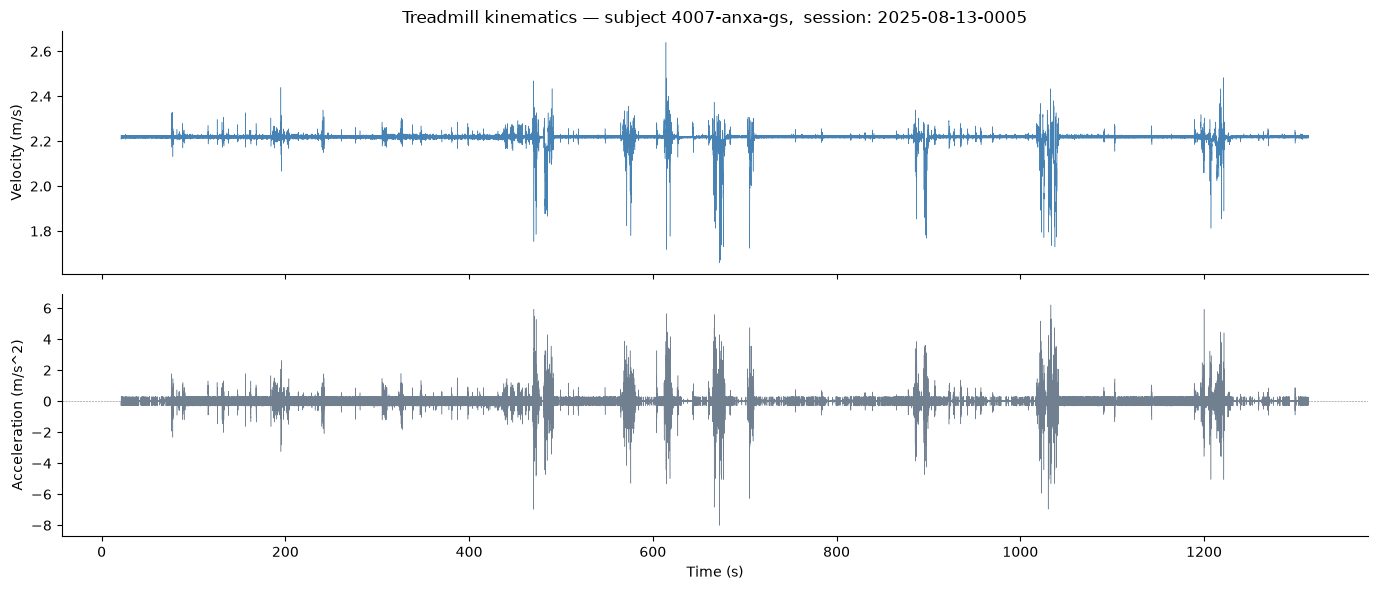

In [33]:
vel_ts  = bts.time_series["treadmill_velocity"]
acc_ts  = bts.time_series["treadmill_acceleration"]

vel_data = vel_ts.data[:]
acc_data = acc_ts.data[:]
beh_time = np.asarray(vel_ts.timestamps[:])  # camera trigger times (ABF clock)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(beh_time, vel_data, linewidth=0.35, color="steelblue")
axes[0].set_ylabel(f"Velocity ({vel_ts.unit})")
axes[0].set_title(
    f"Treadmill kinematics — subject {nwbfile.subject.subject_id},  "
    f"session: {nwbfile.session_id}"
)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(beh_time, acc_data, linewidth=0.35, color="slategray")
axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(f"Acceleration ({acc_ts.unit})")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Combined ΔF/F and treadmill velocity

Both signals share the same time base (camera-trigger-aligned at 100 Hz).
ΔF/F is z-scored for display alongside velocity. Optogenetic stimulation
epochs are shaded in red.

The right column shows a 60-second zoom window to reveal sub-second co-modulation.

/var/folders/vv/cv45rgsd39z2bm7hjhh65xm80000gn/T/ipykernel_55283/912767922.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


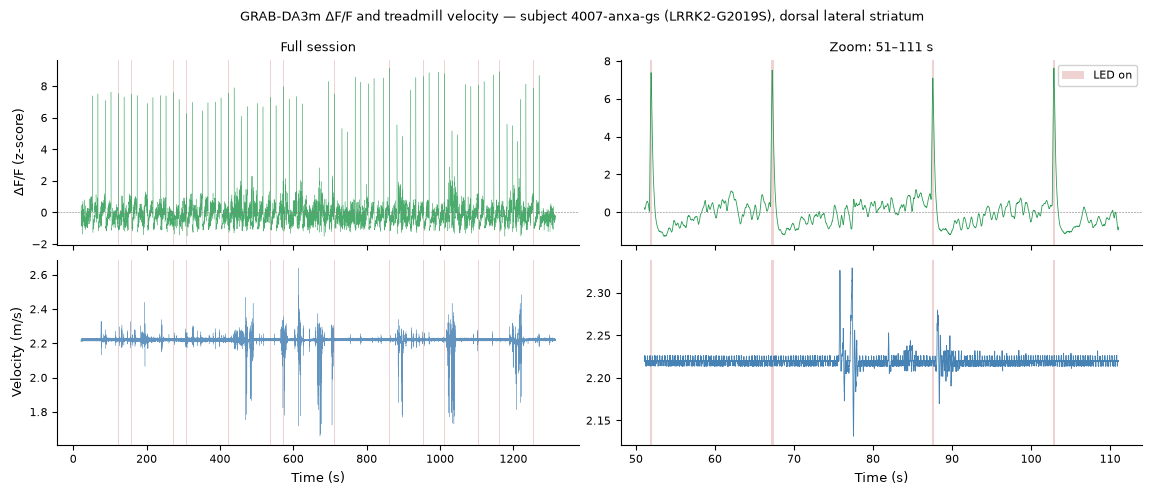

In [34]:
dff_z = (dff_data - dff_data.mean()) / dff_data.std()

_t0_zoom = float(dff_time[0]) + 30.0
_t1_zoom = _t0_zoom + 60.0

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 5),
    sharex="col",
    gridspec_kw={"wspace": 0.08, "hspace": 0.08},
)

def _add_stim_spans(ax, df, t_min=None, t_max=None):
    sub = df if t_min is None else df[
        (df["stop_time"] >= t_min) & (df["start_time"] <= t_max)
    ]
    for i, (_, ep) in enumerate(sub.iterrows()):
        ax.axvspan(ep["start_time"], ep["stop_time"],
                   color="firebrick", alpha=0.20, linewidth=0,
                   label="LED on" if i == 0 else None)

# Full session (left column)
_add_stim_spans(axes[0, 0], opto_df)
axes[0, 0].plot(dff_time, dff_z, linewidth=0.25, color="#2a9d54", alpha=0.85)
axes[0, 0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0, 0].set_ylabel("ΔF/F (z-score)", fontsize=9)
axes[0, 0].set_title("Full session", fontsize=9)
axes[0, 0].spines[["top", "right"]].set_visible(False)

_add_stim_spans(axes[1, 0], opto_df)
axes[1, 0].plot(beh_time, vel_data, linewidth=0.25, color="steelblue", alpha=0.85)
axes[1, 0].set_ylabel(f"Velocity ({vel_ts.unit})", fontsize=9)
axes[1, 0].set_xlabel("Time (s)", fontsize=9)
axes[1, 0].spines[["top", "right"]].set_visible(False)

# 60-second zoom (right column)
_fp_mask  = (dff_time >= _t0_zoom) & (dff_time <= _t1_zoom)
_vel_mask = (beh_time >= _t0_zoom) & (beh_time <= _t1_zoom)

_add_stim_spans(axes[0, 1], opto_df, _t0_zoom, _t1_zoom)
axes[0, 1].plot(dff_time[_fp_mask], dff_z[_fp_mask], linewidth=0.6, color="#2a9d54")
axes[0, 1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0, 1].set_title(f"Zoom: {_t0_zoom:.0f}–{_t1_zoom:.0f} s", fontsize=9)
axes[0, 1].legend(fontsize=8, framealpha=0.9)
axes[0, 1].spines[["top", "right"]].set_visible(False)

_add_stim_spans(axes[1, 1], opto_df, _t0_zoom, _t1_zoom)
axes[1, 1].plot(beh_time[_vel_mask], vel_data[_vel_mask], linewidth=0.6, color="steelblue")
axes[1, 1].set_xlabel("Time (s)", fontsize=9)
axes[1, 1].spines[["top", "right"]].set_visible(False)

for ax in axes.flat:
    ax.tick_params(labelsize=8)

fig.suptitle(
    f"GRAB-DA3m ΔF/F and treadmill velocity — subject {nwbfile.subject.subject_id} "
    f"({nwbfile.subject.genotype}), {fp_table['location'][0]}",
    fontsize=9,
)
plt.tight_layout()
plt.show()

In [36]:
nwbfile.read_io.close()